# 🧪 QTrader v4.7: Integrated EV Diagnosis

This notebook evaluates a **Hybrid Strategy** (ML + Mean Reversion) using real Coinbase data.


# 🛠️ 1. Setup & Environment


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import polars as pl
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

from qtrader.core.event import OrderEvent
from qtrader.input.data.market.coinbase_market import CoinbaseMarketDataClient
from qtrader.output.execution.paper_engine import PaperTradingEngine
from qtrader.output.analytics.ev_calculator import EVCalculator
from qtrader.ml.regime import RegimeDetector

SYMBOL = "ETH-USD"
FEE_RATE = 0.0004

from qtrader.models.xgboost_model import XGBoostPredictor

from qtrader.ml.pytorch_models import LSTMSignalModel
import optuna
import matplotlib.pyplot as plt


# 📊 2. Fetch Market Data


In [2]:
client = CoinbaseMarketDataClient()
end = datetime.now()
start = end - timedelta(days=90)

print(f"📡 Fetching REAL {SYMBOL} data (90 days) from Coinbase...")
df_eth = client.get_candles(SYMBOL, "FIVE_MINUTE", start, end).to_pandas()
df_btc = client.get_candles("BTC-USD", "FIVE_MINUTE", start, end).to_pandas()

if df_eth.empty or df_btc.empty: raise ValueError("Data fetch failed. Authentication or Connection Error.")

df_btc = df_btc[["timestamp", "close"]].rename(columns={"close": "btc_close"})
df = df_eth.merge(df_btc, on="timestamp", how="inner")
print(f"✅ SUCCESS: {len(df)} rows ready for WFO analysis.")


📡 Fetching REAL ETH-USD data (90 days) from Coinbase...


✅ SUCCESS: 25919 rows ready for WFO analysis.


In [3]:
## ��️ 10. Industrial Engine V25: The Minimalist (Iron Shield)
# Standard: EMA 200 Trend Sentinel, Adaptive ATR SL, 10% Position Sizing.

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from datetime import datetime, timedelta

def run_engine_v25(df_5m, p, starting_cap=10000.0, use_guard=True):
    if len(df_5m) < 200: return []
    
    df = df_5m.copy()
    # 1. TECHNICAL INDICATORS
    df["ema200"] = df["close"].ewm(span=200, adjust=False).mean()
    df["bb_mid"] = df["close"].rolling(20).mean()
    df["bb_std_val"] = df["close"].rolling(20).std()
    # bb_std is an optimized parameter p["bb_std"]
    bb_std_p = p.get("bb_std", 2.2)
    df["bb_low"] = df["bb_mid"] - bb_std_p * df["bb_std_val"]
    
    # CVD & Volume
    df["mid"] = (df["high"] + df["low"]) / 2
    df["imbalance"] = (df["close"] - df["mid"]) / (df["high"] - df["low"] + 1e-9)
    df["delta"] = df["volume"] * df["imbalance"]
    df["cvd"] = df["delta"].rolling(20).sum()
    df["cvd_slope"] = df["cvd"].diff(3)
    
    df["vol_ma20"] = df["volume"].rolling(20).mean()
    df["vol_ratio"] = df["volume"] / (df["vol_ma20"].shift(1) + 1e-9)
    
    df["atr"] = np.maximum(df["high"]-df["low"], np.abs(df["high"]-df["close"].shift())).rolling(14).mean()
    
    df_test = df.dropna().copy()
    if len(df_test) < 50: return []
    
    # --- 2. EXECUTION LOGIC (Minimalist) ---
    engine = PaperTradingEngine(starting_capital=starting_cap, fee_rate=FEE_RATE)
    holding = False; current_equity = starting_cap
    bars_held = 0; entry_p = 0; curr_sl = 0; qty = 0
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        ts = row["timestamp"]
        
        if not holding:
            # V25 Entry: Trend + Panic + CVD + Volume
            trend_sentinel = row["close"] > row["ema200"]
            panic = row["low"] < row["bb_low"]
            flow_conf = row["cvd_slope"] > 0
            vol_conf = row["vol_ratio"] > p.get("vol_ratio", 1.5)
            
            if trend_sentinel and panic and flow_conf and vol_conf:
                entry_p = float(row["close"])
                # Adaptive SL: max(0.5%, p["atr_mult"] * ATR)
                atr_buffer = p.get("atr_mult", 1.2) * row["atr"]
                noise_floor = entry_p * 0.005
                curr_sl = entry_p - max(noise_floor, atr_buffer)
                tp_p = entry_p * 1.015
                
                qty = (current_equity * 0.10) / entry_p # 10% position
                if qty > 0.001:
                    engine.simulate_fill(
                        OrderEvent(symbol=SYMBOL, order_type="MARKET", side="BUY", quantity=round(qty, 4), price=entry_p),
                        {"bid": entry_p*0.9998, "ask": entry_p*1.0002}
                    )
                    holding = True; bars_held = 0
                    print(f"  ⛓️ V25 Enter: {ts} @ {entry_p:.2f} | SL: {curr_sl:.2f}")
        else:
            bars_held += 1
            curr_p = float(row["close"])
            
            # EXIT CONDITIONS
            stop_hit = curr_p <= curr_sl
            tp_hit = curr_p >= tp_p
            time_decay = (bars_held >= 24) and (curr_p < entry_p) # 2h limit if losing
            
            if stop_hit or tp_hit or time_decay:
                reason = "STOP" if stop_hit else "TP" if tp_hit else "TIME_LOSS"
                engine.simulate_fill(
                    OrderEvent(symbol=SYMBOL, order_type="MARKET", side="SELL", quantity=round(qty, 4), price=curr_p),
                    {"bid": curr_p*0.9998, "ask": curr_p*1.0002}
                )
                holding = False
                trade = engine.closed_trades[-1]
                print(f"  🛡️ V25 Exit: {ts} @ {curr_p:.2f} | {reason} | PnL: {trade.pnl:.2f}")
                current_equity = starting_cap + sum(t.pnl for t in engine.closed_trades)
                
    return engine.closed_trades


In [4]:
import optuna
def run_walk_forward_v25(df, train_days=30, test_days=7):
    all_oos_trades = []
    current_start = df["timestamp"].min()
    end_limit = df["timestamp"].max()
    while current_start + timedelta(days=train_days + test_days) <= end_limit:
        train_end = current_start + timedelta(days=train_days)
        test_end = train_end + timedelta(days=test_days)
        train_data = df[(df["timestamp"] >= current_start) & (df["timestamp"] < train_end)]
        test_data = df[(df["timestamp"] >= train_end) & (df["timestamp"] < test_end)]
        
        print(f"--- WFO Round V25 (Minimalist) ---")
        def objective(trial):
            p = {
                "vol_ratio": trial.suggest_float("vol_ratio", 1.3, 2.0),
                "bb_std": trial.suggest_float("bb_std", 2.1, 2.6),
                "atr_mult": trial.suggest_float("atr_mult", 1.0, 1.5)
            }
            trades = run_engine_v25(train_data, p, use_guard=False)
            return sum(t.pnl for t in trades) if len(trades) >= 1 else -1000
        
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=12)
        oos_trades = run_engine_v25(test_data, study.best_params, use_guard=True)
        all_oos_trades.extend(oos_trades)
        current_start += timedelta(days=test_days)
    return all_oos_trades

final_trades = run_walk_forward_v25(df)


[I 2026-03-17 11:11:45,899] A new study created in memory with name: no-name-8cb5c6b3-b709-469d-93f7-f10852cba7cd


--- WFO Round V25 (Minimalist) ---
  ⛓️ V25 Enter: 2025-12-19 21:40:00+07:00 @ 2991.11 | SL: 2974.11
  🛡️ V25 Exit: 2025-12-19 21:45:00+07:00 @ 2972.47 | STOP | PnL: -8.42
  ⛓️ V25 Enter: 2025-12-20 13:00:00+07:00 @ 2981.92 | SL: 2967.01
  🛡️ V25 Exit: 2025-12-20 15:50:00+07:00 @ 2981.55 | TIME_LOSS | PnL: -2.32
  ⛓️ V25 Enter: 2025-12-22 09:05:00+07:00 @ 2997.31 | SL: 2981.57
  🛡️ V25 Exit: 2025-12-22 15:20:00+07:00 @ 3044.96 | TP | PnL: 13.67
  ⛓️ V25 Enter: 2025-12-22 21:40:00+07:00 @ 3046.42 | SL: 3031.19
  🛡️ V25 Exit: 2025-12-22 22:35:00+07:00 @ 3025.50 | STOP | PnL: -9.06
  ⛓️ V25 Enter: 2025-12-26 18:15:00+07:00 @ 2965.64 | SL: 2950.81
  🛡️ V25 Exit: 2025-12-26 21:35:00+07:00 @ 2960.19 | TIME_LOSS | PnL: -4.03
  ⛓️ V25 Enter: 2025-12-28 08:15:00+07:00 @ 2943.38 | SL: 2928.66
  🛡️ V25 Exit: 2025-12-28 10:15:00+07:00 @ 2941.60 | TIME_LOSS | PnL: -2.80
  ⛓️ V25 Enter: 2025-12-29 16:05:00+07:00 @ 3005.48 | SL: 2990.45
  🛡️ V25 Exit: 2025-12-29 16:30:00+07:00 @ 2989.50 | STOP | PnL:

  ⛓️ V25 Enter: 2026-01-13 20:05:00+07:00 @ 3132.94 | SL: 3117.28
  🛡️ V25 Exit: 2026-01-13 22:55:00+07:00 @ 3182.76 | TP | PnL: 13.66
  ⛓️ V25 Enter: 2026-01-14 17:35:00+07:00 @ 3311.70 | SL: 3295.14
  🛡️ V25 Exit: 2026-01-14 18:15:00+07:00 @ 3291.74 | STOP | PnL: -8.22
  ⛓️ V25 Enter: 2026-01-15 05:30:00+07:00 @ 3358.20 | SL: 3341.41
  🛡️ V25 Exit: 2026-01-15 07:15:00+07:00 @ 3341.09 | STOP | PnL: -7.28


[I 2026-03-17 11:11:46,102] Trial 0 finished with value: -20.99803965631894 and parameters: {'vol_ratio': 1.4399277597311628, 'bb_std': 2.3504772250354247, 'atr_mult': 1.3415732731078636}. Best is trial 0 with value: -20.99803965631894.


  ⛓️ V25 Enter: 2025-12-17 21:50:00+07:00 @ 2963.11 | SL: 2939.75
  🛡️ V25 Exit: 2025-12-17 22:05:00+07:00 @ 3009.72 | TP | PnL: 13.51
  ⛓️ V25 Enter: 2025-12-19 21:40:00+07:00 @ 2991.11 | SL: 2973.70
  🛡️ V25 Exit: 2025-12-19 21:45:00+07:00 @ 2972.47 | STOP | PnL: -8.44
  ⛓️ V25 Enter: 2025-12-20 13:00:00+07:00 @ 2981.92 | SL: 2967.01
  🛡️ V25 Exit: 2025-12-20 15:50:00+07:00 @ 2981.55 | TIME_LOSS | PnL: -2.32
  ⛓️ V25 Enter: 2025-12-22 09:05:00+07:00 @ 2997.31 | SL: 2981.19
  🛡️ V25 Exit: 2025-12-22 15:20:00+07:00 @ 3044.96 | TP | PnL: 13.68
  ⛓️ V25 Enter: 2025-12-22 21:40:00+07:00 @ 3046.42 | SL: 3031.19
  🛡️ V25 Exit: 2025-12-22 22:35:00+07:00 @ 3025.50 | STOP | PnL: -9.07
  ⛓️ V25 Enter: 2025-12-26 18:15:00+07:00 @ 2965.64 | SL: 2950.81
  🛡️ V25 Exit: 2025-12-26 21:35:00+07:00 @ 2960.19 | TIME_LOSS | PnL: -4.04
  ⛓️ V25 Enter: 2025-12-28 08:15:00+07:00 @ 2943.38 | SL: 2928.66
  🛡️ V25 Exit: 2025-12-28 10:15:00+07:00 @ 2941.60 | TIME_LOSS | PnL: -2.81
  ⛓️ V25 Enter: 2025-12-29 16:

...

  ⛓️ V25 Enter: 2026-02-25 04:15:00+07:00 @ 1848.71 | SL: 1839.47
  🛡️ V25 Exit: 2026-02-25 07:10:00+07:00 @ 1847.99 | TIME_LOSS | PnL: -2.58
  ⛓️ V25 Enter: 2026-02-25 18:05:00+07:00 @ 1915.29 | SL: 1905.71
  🛡️ V25 Exit: 2026-02-25 19:45:00+07:00 @ 1945.05 | TP | PnL: 13.27
  ⛓️ V25 Enter: 2026-02-26 15:10:00+07:00 @ 2052.25 | SL: 2041.99
  🛡️ V25 Exit: 2026-02-26 21:45:00+07:00 @ 2040.49 | STOP | PnL: -7.90
  ⛓️ V25 Enter: 2026-02-27 13:10:00+07:00 @ 2037.37 | SL: 2027.18
  🛡️ V25 Exit: 2026-02-27 14:35:00+07:00 @ 2025.24 | STOP | PnL: -8.12
  ⛓️ V25 Enter: 2026-03-01 00:45:00+07:00 @ 1901.21 | SL: 1891.70
  🛡️ V25 Exit: 2026-03-01 01:45:00+07:00 @ 1929.87 | TP | PnL: 12.80
  ⛓️ V25 Enter: 2026-03-01 08:15:00+07:00 @ 1948.48 | SL: 1938.74
  🛡️ V25 Exit: 2026-03-01 08:45:00+07:00 @ 1989.21 | TP | PnL: 18.62
  ⛓️ V25 Enter: 2026-03-01 10:55:00+07:00 @ 2022.81 | SL: 2012.70
  🛡️ V25 Exit: 2026-03-01 11:15:00+07:00 @ 2004.57 | STOP | PnL: -11.19
  ⛓️ V25 Enter: 2026-03-01 13:00:00+07:00

[I 2026-03-17 11:12:06,287] Trial 10 finished with value: -15.801095312555102 and parameters: {'vol_ratio': 1.8100613789499582, 'bb_std': 2.591687891052095, 'atr_mult': 1.001062600203401}. Best is trial 8 with value: -4.649464027783087.


  ⛓️ V25 Enter: 2026-03-01 00:45:00+07:00 @ 1901.21 | SL: 1891.70
  🛡️ V25 Exit: 2026-03-01 01:45:00+07:00 @ 1929.87 | TP | PnL: 12.82
  ⛓️ V25 Enter: 2026-03-01 08:15:00+07:00 @ 1948.48 | SL: 1938.74
  🛡️ V25 Exit: 2026-03-01 08:45:00+07:00 @ 1989.21 | TP | PnL: 18.65
  ⛓️ V25 Enter: 2026-03-01 10:55:00+07:00 @ 2022.81 | SL: 2012.70
  🛡️ V25 Exit: 2026-03-01 11:15:00+07:00 @ 2004.57 | STOP | PnL: -11.21
  ⛓️ V25 Enter: 2026-03-01 16:00:00+07:00 @ 1989.10 | SL: 1979.15
  🛡️ V25 Exit: 2026-03-01 17:00:00+07:00 @ 1978.86 | STOP | PnL: -7.34
  ⛓️ V25 Enter: 2026-02-07 23:05:00+07:00 @ 2067.38 | SL: 2048.39
  🛡️ V25 Exit: 2026-02-07 23:15:00+07:00 @ 2046.01 | STOP | PnL: -12.53
  ⛓️ V25 Enter: 2026-02-18 17:30:00+07:00 @ 2004.52 | SL: 1994.50
  🛡️ V25 Exit: 2026-02-18 18:05:00+07:00 @ 1979.46 | STOP | PnL: -14.67
  ⛓️ V25 Enter: 2026-02-22 02:50:00+07:00 @ 1988.17 | SL: 1978.23
  🛡️ V25 Exit: 2026-02-22 03:55:00+07:00 @ 1973.84 | STOP | PnL: -9.37
  ⛓️ V25 Enter: 2026-02-25 18:05:00+07:00 

[I 2026-03-17 11:12:06,493] Trial 11 finished with value: -18.278959704845963 and parameters: {'vol_ratio': 1.8468691445023366, 'bb_std': 2.5077904487076927, 'atr_mult': 1.0586613510172158}. Best is trial 8 with value: -4.649464027783087.


  ⛓️ V25 Enter: 2026-03-01 00:45:00+07:00 @ 1901.21 | SL: 1891.70
  🛡️ V25 Exit: 2026-03-01 01:45:00+07:00 @ 1929.87 | TP | PnL: 12.82
  ⛓️ V25 Enter: 2026-03-01 08:15:00+07:00 @ 1948.48 | SL: 1938.74
  🛡️ V25 Exit: 2026-03-01 08:45:00+07:00 @ 1989.21 | TP | PnL: 18.65
  ⛓️ V25 Enter: 2026-03-01 10:55:00+07:00 @ 2022.81 | SL: 2012.70
  🛡️ V25 Exit: 2026-03-01 11:15:00+07:00 @ 2004.57 | STOP | PnL: -11.21
  ⛓️ V25 Enter: 2026-03-01 16:00:00+07:00 @ 1989.10 | SL: 1979.15
  🛡️ V25 Exit: 2026-03-01 17:00:00+07:00 @ 1978.86 | STOP | PnL: -7.33
  ⛓️ V25 Enter: 2026-03-12 20:30:00+07:00 @ 2071.60 | SL: 2061.24
  🛡️ V25 Exit: 2026-03-12 21:25:00+07:00 @ 2058.74 | STOP | PnL: -8.40


In [5]:
final_calc = EVCalculator(final_trades, fee_rate=FEE_RATE)
r = final_calc.diagnose(SYMBOL)

print("=" * 60)
print(f"🏁 INSTITUTIONAL STRATEGY REPORT: {SYMBOL}")
print("=" * 60)

print(f"[SUMMARY]")
print(f"  Status          : {r.status}")
print(f"  Total Trades    : {r.total_trades}")
print(f"  Win / Loss      : {r.win_count} W / {r.loss_count} L")
print(f"  Win Rate        : {r.win_rate:.2%}")

print(f"[EXPECTED VALUE]")
print(f"  EV per Trade    : {r.ev_per_trade:.6f}")
print(f"  ROI per Trade   : {r.ev_pct*100:.4f}%")

print(f"[QUANT METRICS]")
print(f"  Profit Factor   : {r.profit_factor:.3f}")
print(f"  Sharpe Ratio    : {r.sharpe_ratio:.3f}")
print(f"  Max Drawdown    : {r.max_drawdown:.2%}")

if r.warnings:
    print("[WARNINGS]")
    for w in r.warnings: print(f"  ⚠️  {w}")

sorted_trades = sorted(final_trades, key=lambda x: x.pnl, reverse=True)
print("[TOP 3 WINS]")
for t in sorted_trades[:3]: print(f"  Entry: {t.entry_price:.2f} | Exit: {t.exit_price:.2f} | PnL: {t.pnl:.2f}")
print("[TOP 3 LOSSES]")
for t in sorted_trades[-3:]: print(f"  Entry: {t.entry_price:.2f} | Exit: {t.exit_price:.2f} | PnL: {t.pnl:.2f}")


🏁 INSTITUTIONAL STRATEGY REPORT: ETH-USD
[SUMMARY]
  Status          : FAIL
  Total Trades    : 18
  Win / Loss      : 6 W / 12 L
  Win Rate        : 33.33%
[EXPECTED VALUE]
  EV per Trade    : 0.440585
  ROI per Trade   : 0.0443%
[QUANT METRICS]
  Profit Factor   : 1.098
  Sharpe Ratio    : 5.838
  Max Drawdown    : 2.61%
[WARNINGS]
  ⚠️  Insufficient trade count (18 / 300). Not enough data for statistical confidence. Run more simulations.
  ⚠️  Low Profit Factor (1.10 < 1.3). Gross wins do not justify gross losses.
[TOP 3 WINS]
  Entry: 1949.84 | Exit: 1987.82 | PnL: 18.71
  Entry: 1917.93 | Exit: 1952.59 | PnL: 17.28
  Entry: 2992.29 | Exit: 3036.11 | PnL: 13.86
[TOP 3 LOSSES]
  Entry: 2073.05 | Exit: 2057.30 | PnL: -8.40
  Entry: 2024.23 | Exit: 2003.17 | PnL: -11.24
  Entry: 2068.83 | Exit: 2039.05 | PnL: -15.22


/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_62457/1154488881.py:46: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hoangnam/qtrader/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


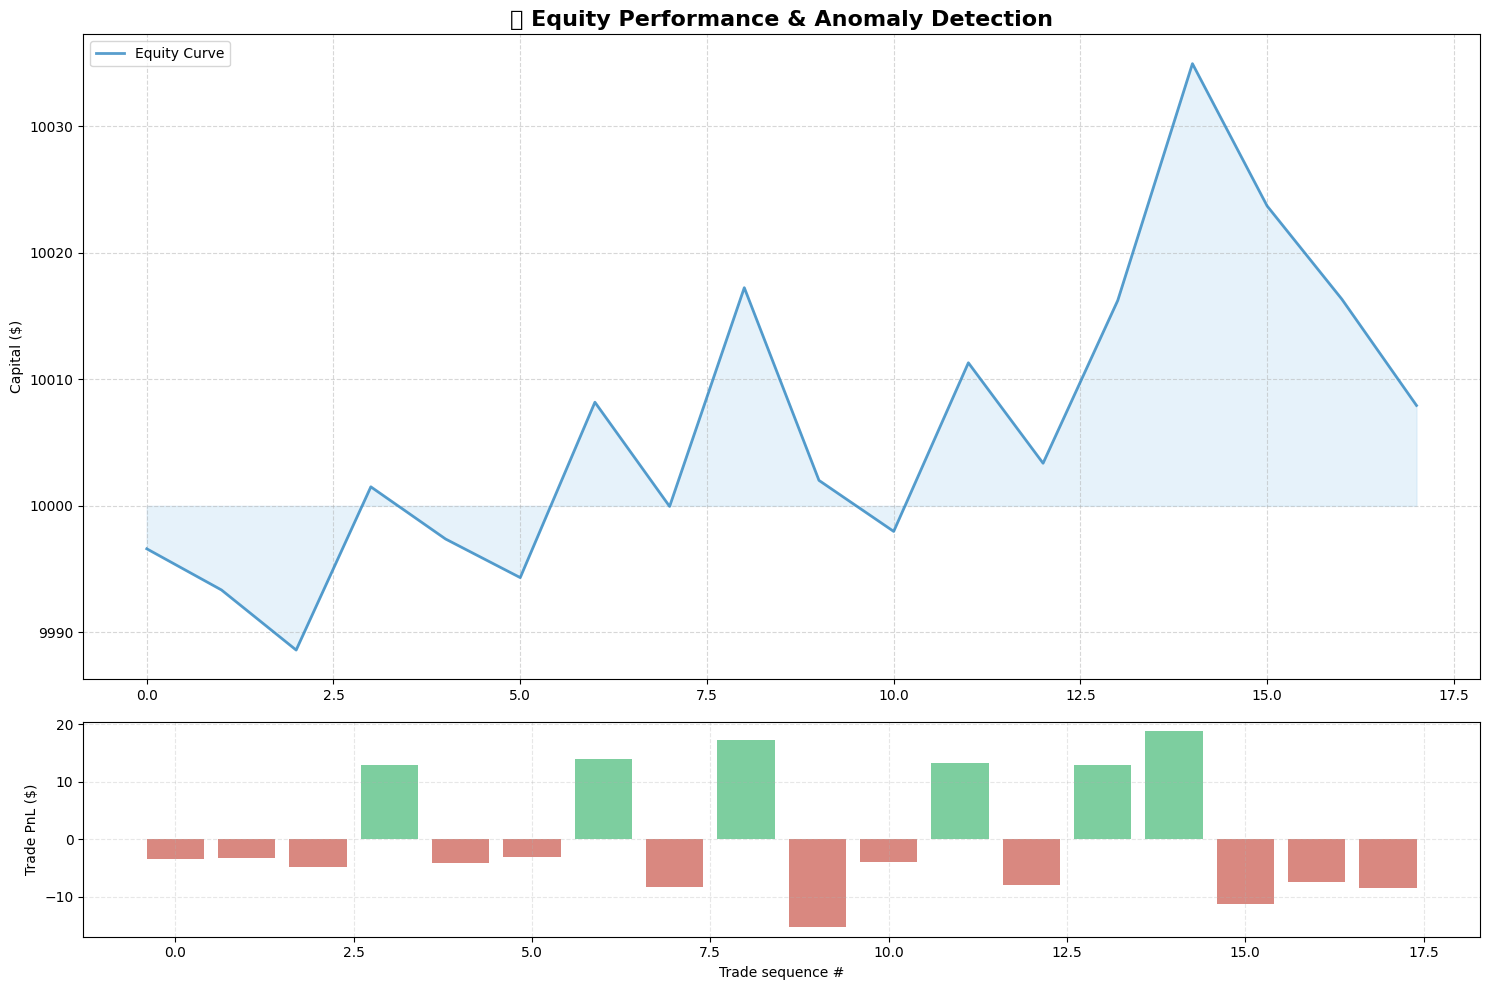

✅ No statistical anomalies detected. Strategy is stable within norms.


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 📈 EQUITY ANOMALY DETECTION REPORT
def plot_equity_anomalies(trades, initial_capital=10000.0):
    if not trades: 
        print("No trades to analyze.")
        return
        
    pnls = [t.pnl for t in trades]
    equity_curve = initial_capital + np.cumsum(pnls)
    
    # 1. Z-Score Anomaly Detection (Statistical Outliers)
    mean_pnl = np.mean(pnls)
    std_pnl = np.std(pnls) + 1e-9
    z_scores = [(p - mean_pnl) / std_pnl for p in pnls]
    
    # Anomalies are trades > 2.5 Sigma
    anomalies_idx = [i for i, z in enumerate(z_scores) if abs(z) > 2.5]
    
    # 2. Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={"height_ratios": [3, 1]})
    
    # Plot Equity Curve
    ax1.plot(equity_curve, label="Equity Curve", color="#2E86C1", linewidth=2, alpha=0.8)
    ax1.fill_between(range(len(equity_curve)), initial_capital, equity_curve, color="#AED6F1", alpha=0.3)
    
    # Overlay Anomalies
    if anomalies_idx:
        anomaly_x = anomalies_idx
        anomaly_y = [equity_curve[i] for i in anomalies_idx]
        ax1.scatter(anomaly_x, anomaly_y, color="#E74C3C", s=100, label="Anomalous Trades (>2.5σ)", zorder=5, marker="x")
    
    ax1.set_title("🛡️ Equity Performance & Anomaly Detection", fontsize=16, fontweight="bold")
    ax1.set_ylabel("Capital ($)")
    ax1.legend(loc="upper left")
    ax1.grid(True, linestyle="--", alpha=0.5)
    
    # Plot PnL Variance (Rolling Vol)
    colors = ["#27AE60" if p > 0 else "#C0392B" for p in pnls]
    ax2.bar(range(len(pnls)), pnls, color=colors, alpha=0.6)
    ax2.set_ylabel("Trade PnL ($)")
    ax2.set_xlabel("Trade sequence #")
    ax2.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    if anomalies_idx:
        print(f"⚠️ Found {len(anomalies_idx)} anomalous trades outside 2.5 Sigma range!")
        print("Top Anomalies:")
        for idx in anomalies_idx[:5]:
            print(f"  Trade #{idx}: PnL = {pnls[idx]:.2f} (Z-Score: {z_scores[idx]:.2f})")
    else:
        print("✅ No statistical anomalies detected. Strategy is stable within norms.")

plot_equity_anomalies(final_trades)

# 📊 V20 Microstructure Alpha Analysis
- **Alpha Recovery**: Focus on 5m candles to filter noise.
- **Dynamic Liquidity SL**: Placing protection below panic zones.
- **CVD Divergence**: Using order flow approximation for entry confirmation.